In [1]:
#EXP = 7
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

def download_image(url, name):
    urllib.request.urlretrieve(url, name)
    return cv2.imread(name)

img_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/butterfly.jpg"
img = download_image(img_url, "butterfly.jpg")
print(f"Image  loaded successfully, Original shape: {img.shape}")

Image  loaded successfully, Original shape: (356, 493, 3)


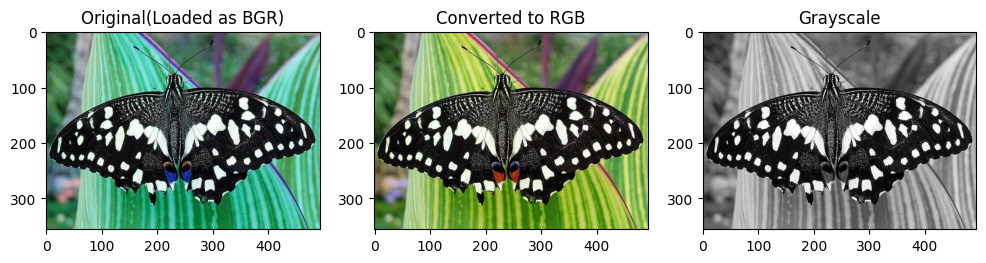

In [2]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(12,6))
plt.subplot(1,3,1); plt.imshow(img); plt.title("Original(Loaded as BGR)")
plt.subplot(1,3,2); plt.imshow(img_rgb); plt.title("Converted to RGB")
plt.subplot(1,3,3); plt.imshow(img_gray, cmap="gray"); plt.title("Grayscale")
plt.show()

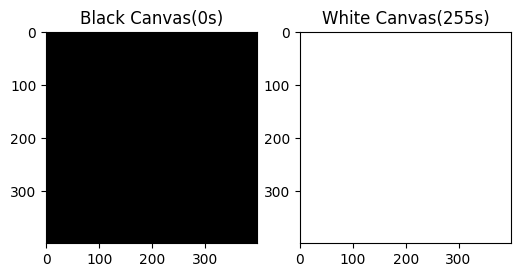

In [3]:
black_canvas = np.zeros((400,400,3),dtype="uint8")
white_canvas = np.ones((400,400,3), dtype = "uint8") *255
plt.figure(figsize = (6,4))
plt.subplot(1,2,1); plt.imshow(black_canvas); plt.title("Black Canvas(0s)")
plt.subplot(1,2,2); plt.imshow(white_canvas); plt.title("White Canvas(255s)")
plt.show()

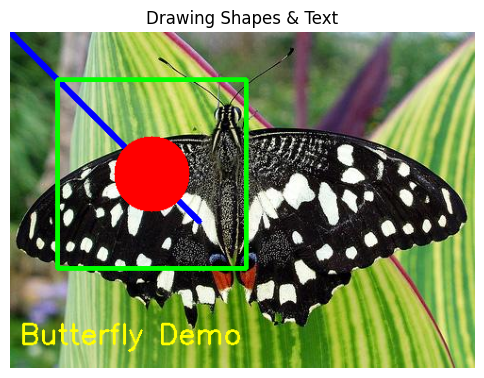

In [4]:
drawing_demo = img_rgb.copy()
cv2.line(drawing_demo,(0,0),(200,200),(0,0,255),5)
cv2.rectangle(drawing_demo, (50,50),(250,250),(0,255,0),3)
cv2.circle(drawing_demo,(150,150),40,(255,0,0),-1)
cv2.putText(drawing_demo, "Butterfly Demo",(10,330),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,0),2)
plt.figure(figsize=(6,6))
plt.imshow(drawing_demo)
plt.title("Drawing Shapes & Text")
plt.axis('off')
plt.show()

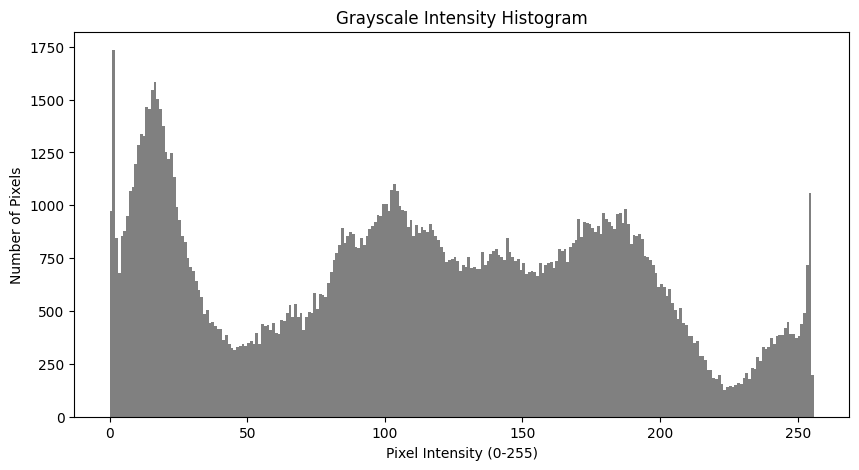

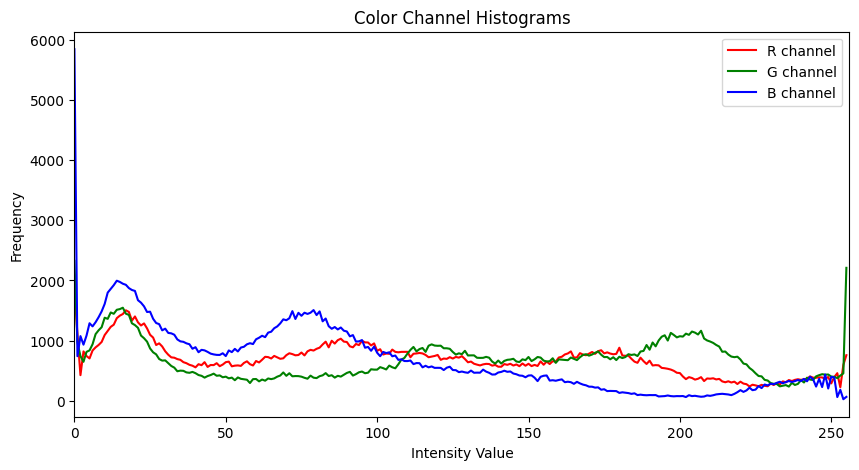

In [5]:
# 1. Grayscale Histogram (Overall Intensity)
plt.figure(figsize=(10, 5))
plt.title("Grayscale Intensity Histogram")
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Number of Pixels")

# Use plt.hist to calculate and plot in one go
# .ravel() flattens the 2D image into a 1D array
plt.hist(img_gray.ravel(), bins=256, range=[0, 256], color='gray')
plt.show()

# 2. Color Channel Histograms
plt.figure(figsize=(10, 5))
plt.title("Color Channel Histograms")
plt.xlabel("Intensity Value")
plt.ylabel("Frequency")

colors = ('r', 'g', 'b')
# OpenCV loads as BGR, but we previously converted 'img_rgb' to RGB
for i, col in enumerate(colors):
    hist = cv2.calcHist([img_rgb], [i], None, [256], [0, 256])
    plt.plot(hist, color=col, label=f'{col.upper()} channel')
    plt.xlim([0, 256])

plt.legend()
plt.show()